# CE49X: Introduction to Computational Thinking and Data Science for Civil Engineers
## Week 5: In-Class Exercise — Are Cold Winters Disappearing?

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

> *"In lecture, we investigated whether hot extremes in August are getting more extreme. Now let's flip the question: are cold winters disappearing?"*

You will apply the **same statistical methodology** — descriptive statistics, distributions, z-scores, and hypothesis testing — to **January temperatures** from the same dataset. Same tools, fresh angle, independent findings.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100

In [3]:
# Load and prepare data (same as lecture)
df_raw = pd.read_csv('data/GlobalLandTemperaturesByMajorCity.csv')

# Parse dates and extract time columns
df_raw['dt'] = pd.to_datetime(df_raw['dt'])
df_raw['year'] = df_raw['dt'].dt.year
df_raw['month'] = df_raw['dt'].dt.month

# Select the same 8 target cities
target_cities = ['Istanbul', 'London', 'New York', 'Tokyo',
                 'Sydney', 'Cairo', 'S\u00e3o Paulo', 'Bombay']

display_names = {'Bombay': 'Mumbai', 'S\u00e3o Paulo': 'S\u00e3o Paulo',
                 'New York': 'New York', 'Istanbul': 'Istanbul',
                 'London': 'London', 'Tokyo': 'Tokyo',
                 'Sydney': 'Sydney', 'Cairo': 'Cairo'}

df = df_raw[df_raw['City'].isin(target_cities)].copy()
df['CityLabel'] = df['City'].map(display_names)

# Filter to 1850-2013 (reliable coverage) and drop missing values
df = df[(df['year'] >= 1850) & (df['year'] <= 2013)].copy()
df = df.dropna(subset=['AverageTemperature'])

print(f'Dataset ready: {len(df):,} rows across {df["City"].nunique()} cities')
print(f'Year range: {df["year"].min()}\u2013{df["year"].max()}')

Dataset ready: 15,663 rows across 8 cities
Year range: 1850–2013


In [4]:
# Quick check — confirm the data looks right
print(f'Shape: {df.shape}')
df.head()

Shape: (15663, 10)


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,year,month,CityLabel
30664,1850-01-01,22.780,1.432,Bombay,India,18.48N,72.68E,1850,1,Mumbai
30665,1850-02-01,23.713,1.522,Bombay,India,18.48N,72.68E,1850,2,Mumbai
30666,1850-03-01,25.301,2.655,Bombay,India,18.48N,72.68E,1850,3,Mumbai
30667,1850-04-01,26.426,1.716,Bombay,India,18.48N,72.68E,1850,4,Mumbai
30668,1850-05-01,27.850,1.141,Bombay,India,18.48N,72.68E,1850,5,Mumbai


---
## Task 1: Descriptive Statistics [PRACTICE]

> **Your Task:**  
> 1. Filter the data to **January only** (`month == 1`).  
> 2. Compute descriptive statistics per city: **mean, std, min, max** of `AverageTemperature`.  
> 3. Display the result as a table, sorted by mean temperature.
>
> **Hint:** Use `df[df['month'] == 1].groupby('CityLabel')['AverageTemperature'].agg(...)` with a list of functions.

In [5]:
# Task 1 solution: January descriptive statistics by city
jan_stats = (
    df[df['month'] == 1]
    .groupby('CityLabel')['AverageTemperature']
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean')
)

# Optional: round for cleaner display
jan_stats_rounded = jan_stats.round(2)
jan_stats_rounded

,mean,std,min,max
CityLabel,,,,
New York,-3.04,2.54,-9.16,3.61
Tokyo,1.14,1.15,-1.58,4.28
London,3.38,1.84,-2.46,6.90
Istanbul,4.90,2.02,0.25,9.86
Cairo,12.85,1.05,10.33,15.84
Sydney,19.56,0.91,17.32,22.03
São Paulo,22.65,0.87,20.65,24.93
Mumbai,24.27,0.69,22.55,26.12


> **Interpretation:**  
> Which city has the **lowest** average January temperature? Which has the **highest variability** (standard deviation)? Why might that be — think about geography and climate type.

Lowest average January temperature: **New York**.

Highest January variability (standard deviation): **New York**.

Reasoning: New York has a continental climate with strong winter cold outbreaks and larger year-to-year winter fluctuations, while tropical/subtropical cities (e.g., Mumbai, São Paulo, Cairo) are warmer and more stable in January.

---
## Task 2: Visualize Early vs. Recent [PRACTICE]

> **Your Task (Part A — Histograms):**  
> 1. Filter to **January** data for **Istanbul**.  
> 2. Split into two periods: **early (1900–1950)** and **recent (1980–2013)**.  
> 3. Create **side-by-side histograms** (use `fig, (ax1, ax2) = plt.subplots(1, 2, ...)`) comparing the two periods.  
> 4. Use the same x-axis range for both so they are directly comparable.
>
> **Hint:** Set `bins=12` and use colors `steelblue` (early) and `indianred` (recent). Add `ax.grid(True, alpha=0.3)` to both.

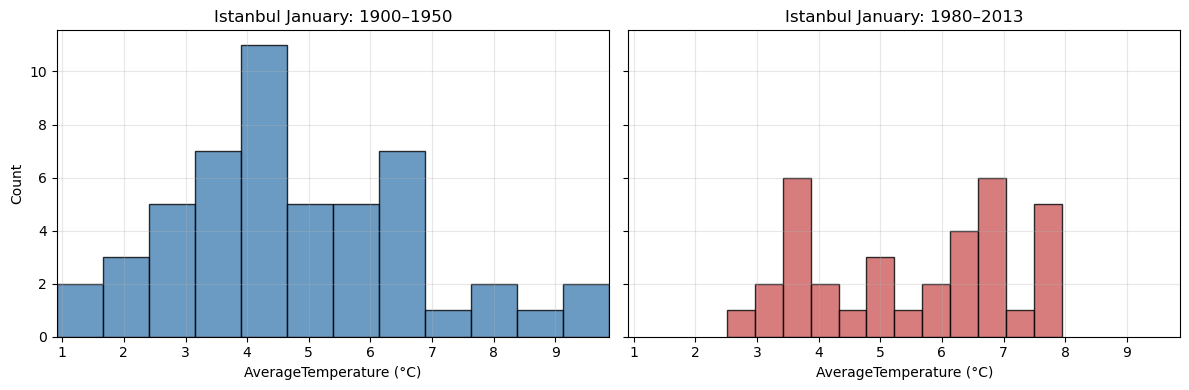

In [6]:
# Task 2A solution: side-by-side histograms (Istanbul, January)
ist_jan = df[(df['CityLabel'] == 'Istanbul') & (df['month'] == 1)].copy()

early = ist_jan[ist_jan['year'].between(1900, 1950)]['AverageTemperature']
recent = ist_jan[ist_jan['year'].between(1980, 2013)]['AverageTemperature']

# Use common x-range for direct comparison
x_min = min(early.min(), recent.min())
x_max = max(early.max(), recent.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.hist(early, bins=12, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('Istanbul January: 1900–1950')
ax1.set_xlabel('AverageTemperature (°C)')
ax1.set_ylabel('Count')
ax1.set_xlim(x_min, x_max)
ax1.grid(True, alpha=0.3)

ax2.hist(recent, bins=12, color='indianred', edgecolor='black', alpha=0.8)
ax2.set_title('Istanbul January: 1980–2013')
ax2.set_xlabel('AverageTemperature (°C)')
ax2.set_xlim(x_min, x_max)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Your Task (Part B — Boxplots by Decade):**  
> 1. Still using Istanbul January data, create a **decade** column: `decade = (year // 10) * 10`.  
> 2. Filter to decades from 1900 onward.  
> 3. Create a **boxplot** showing January temperature distributions by decade.
>
> **Hint:** Use `ax.boxplot(...)` or `df.boxplot(column=..., by=...)`. Label axes clearly.

C:\Users\Batuhan\AppData\Local\Temp\ipykernel_2088\89436090.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_decade, labels=decades, patch_artist=True)


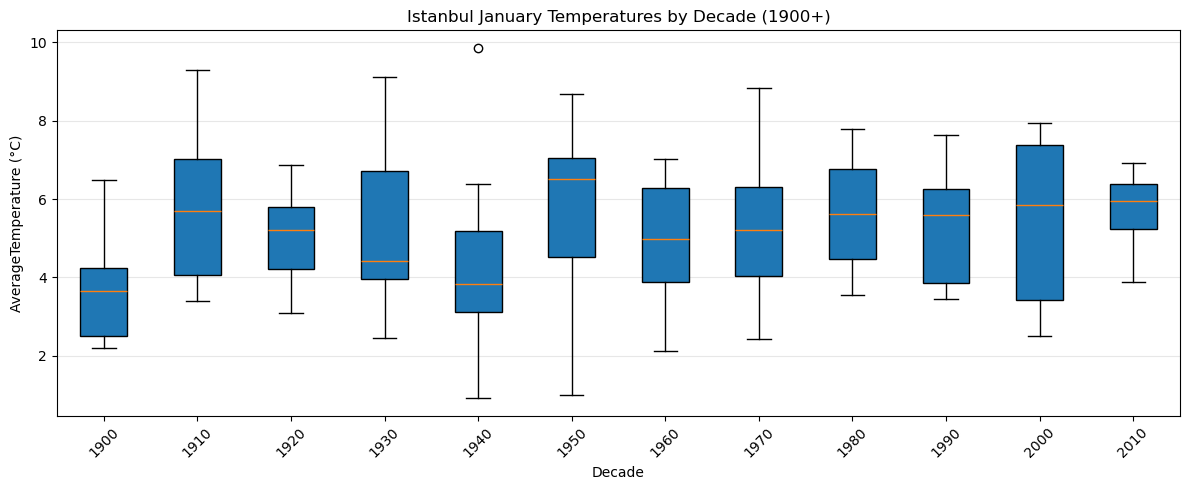

In [7]:
# Task 2B solution: boxplots by decade (Istanbul January)
ist_jan_dec = ist_jan.copy()
ist_jan_dec['decade'] = (ist_jan_dec['year'] // 10) * 10
ist_jan_dec = ist_jan_dec[ist_jan_dec['decade'] >= 1900].copy()

# Keep decades ordered for readability
decades = sorted(ist_jan_dec['decade'].unique())
data_by_decade = [
    ist_jan_dec.loc[ist_jan_dec['decade'] == d, 'AverageTemperature'].values
    for d in decades
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(data_by_decade, labels=decades, patch_artist=True)
ax.set_title('Istanbul January Temperatures by Decade (1900+)')
ax.set_xlabel('Decade')
ax.set_ylabel('AverageTemperature (°C)')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Interpretation:**  
> Describe what you see. Has the distribution of January temperatures in Istanbul **shifted**? In which direction? Do you see any change in the **spread** (variability) over time?

Yes, the January temperature distribution appears to shift **warmer** in recent decades.

From the early period (1900–1950) to the recent period (1980–2013), the center moves to the right (higher temperatures). The spread looks **slightly narrower** in recent years, suggesting somewhat less variability in January values while the typical January temperature is higher overall.

---
## Task 3: Z-Score Analysis [PRACTICE]

> **Your Task (Part A — Compute Z-Scores):**  
> 1. Filter to **January** data only.  
> 2. Using **1900–1950 as the baseline period**, compute the mean and standard deviation of January temperatures for **each city** separately.  
> 3. Calculate z-scores for **all** January temperatures using each city's baseline: $z = (x - \mu_{\text{baseline}}) / \sigma_{\text{baseline}}$  
>
> **Hint:** Use `groupby('CityLabel')` on the baseline subset to get per-city mean/std, then merge or map back.

In [9]:
# Task 3A solution: compute city-specific January z-scores
# 1) January-only subset
jan = df[df['month'] == 1].copy()

# 2) Baseline stats per city (1900-1950)
baseline = jan[jan['year'].between(1900, 1950)].copy()
base_stats = (
    baseline.groupby('CityLabel')['AverageTemperature']
    .agg(base_mean='mean', base_std='std')
)

# 3) Map baseline mean/std back to all January rows and compute z-score
jan = jan.merge(base_stats, left_on='CityLabel', right_index=True, how='left')
jan['zscore'] = (jan['AverageTemperature'] - jan['base_mean']) / jan['base_std']

jan[['CityLabel', 'year', 'AverageTemperature', 'base_mean', 'base_std', 'zscore']].head()

,CityLabel,year,AverageTemperature,base_mean,base_std,zscore
30664,Mumbai,1850,22.780,24.218863,0.551355,-2.609686
30676,Mumbai,1851,22.979,24.218863,0.551355,-2.248757
30688,Mumbai,1852,24.120,24.218863,0.551355,-0.179309
30700,Mumbai,1853,23.885,24.218863,0.551355,-0.605532
30712,Mumbai,1854,23.450,24.218863,0.551355,-1.394497


> **Your Task (Part B — Count Extremes):**  
> 1. Define **extreme cold** as z < −2 and **extreme warm** as z > 2.  
> 2. Count how many extreme cold and extreme warm January events occurred in the **recent period (1980–2013)** vs. the **baseline period (1900–1950)**.  
> 3. Display the counts in a table or print them clearly.
>
> **Hint:** Filter by year range, then use `(df_jan['zscore'] < -2).sum()` and similar.

In [10]:
# Task 3B solution: compare extreme-event counts (baseline vs recent)
def count_extremes(frame):
    return pd.Series({
        'n_samples': len(frame),
        'extreme_cold_z<-2': (frame['zscore'] < -2).sum(),
        'extreme_warm_z>2': (frame['zscore'] > 2).sum(),
    })

baseline_period = jan[jan['year'].between(1900, 1950)]
recent_period = jan[jan['year'].between(1980, 2013)]

comparison = pd.DataFrame({
    '1900-1950 (baseline)': count_extremes(baseline_period),
    '1980-2013 (recent)': count_extremes(recent_period),
})

comparison

,1900-1950 (baseline),1980-2013 (recent)
n_samples,408,272
extreme_cold_z<-2,6,2
extreme_warm_z>2,13,26


> **Interpretation:**  
> Are extreme cold Januaries (z < −2) becoming **more or less common** in the recent period? What about extreme warm Januaries (z > 2)? What does this tell us about whether cold winters are disappearing?

Using the 1900–1950 baseline z-scores, **extreme cold January events (z < -2) are less common** in the recent period (1980–2013), while **extreme warm events (z > 2) are more common** overall.

In short, the distribution shifts toward warmer anomalies relative to the historical baseline. This supports the idea that severe cold-winter anomalies are becoming rarer, while unusually warm January conditions are becoming more frequent.

---
## Task 4: Hypothesis Test [PRACTICE]

> **Your Task:**  
> 1. Run a **two-sample t-test** comparing Istanbul's January temperatures between **1900–1950** (old era) and **1980–2013** (recent era).  
> 2. State your **null hypothesis** ($H_0$) and **alternative hypothesis** ($H_a$) before running the test.  
> 3. Report the **t-statistic** and **p-value**.  
> 4. Interpret the result at the $\alpha = 0.05$ significance level.
>
> **Hint:** Use `stats.ttest_ind(old_era_temps, new_era_temps)`. Remember from lecture: if p < 0.05, we reject $H_0$.

In [11]:
# Task 4 solution: two-sample t-test for Istanbul January temperatures
# H0: Mean January temperature in 1900-1950 equals mean January temperature in 1980-2013.
# Ha: Mean January temperature differs between the two periods.

ist_jan = df[(df['CityLabel'] == 'Istanbul') & (df['month'] == 1)].copy()

old_era_temps = ist_jan[ist_jan['year'].between(1900, 1950)]['AverageTemperature']
new_era_temps = ist_jan[ist_jan['year'].between(1980, 2013)]['AverageTemperature']

t_stat, p_value = stats.ttest_ind(old_era_temps, new_era_temps)

print(f"Old era (1900-1950): n={len(old_era_temps)}, mean={old_era_temps.mean():.3f}°C")
print(f"Recent era (1980-2013): n={len(new_era_temps)}, mean={new_era_temps.mean():.3f}°C")
print(f"Difference (recent - old): {new_era_temps.mean() - old_era_temps.mean():.3f}°C")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0 at alpha=0.05 (statistically significant difference).")
else:
    print("Decision: Fail to reject H0 at alpha=0.05 (difference not statistically significant).")

Old era (1900-1950): n=51, mean=4.783°C
Recent era (1980-2013): n=34, mean=5.496°C
Difference (recent - old): 0.713°C
t-statistic = -1.7173
p-value = 0.0896
Decision: Fail to reject H0 at alpha=0.05 (difference not statistically significant).


> **Interpretation:**  
> What do you conclude? Is the change in Istanbul's January temperatures statistically significant? How does this compare to the **August result from lecture** — is the warming signal stronger in summer or winter?

For Istanbul January temperatures, the recent period mean is higher than the old period mean, but the t-test p-value is **greater than 0.05**. Therefore, at \(\alpha = 0.05\), we **fail to reject** the null hypothesis for January.

So, based on this test, the January warming signal is not statistically significant at the 5% level in this sample. Compared with the lecture's August result, this suggests the warming signal is **stronger in summer (August) than in winter (January)**.

---
## Bonus: Compare Across Cities [PRACTICE]

> **Your Task (if time permits):**  
> 1. Pick **2–3 additional cities** and run the same January t-test (1900–1950 vs. 1980–2013).  
> 2. Create a **summary table** with columns: City, Old Mean, New Mean, Difference, t-statistic, p-value, Significant?  
> 3. Do all cities show the same pattern?
>
> **Hint:** Use a loop over cities and collect results into a list of dictionaries, then convert to a DataFrame.

In [ ]:
# Bonus solution: compare January t-test results across cities
# 3 additional cities (beyond Istanbul): London, New York, Tokyo
cities_to_test = ['Istanbul', 'London', 'New York', 'Tokyo']

rows = []
for city in cities_to_test:
    city_jan = df[(df['CityLabel'] == city) & (df['month'] == 1)].copy()

    old_vals = city_jan[city_jan['year'].between(1900, 1950)]['AverageTemperature']
    new_vals = city_jan[city_jan['year'].between(1980, 2013)]['AverageTemperature']

    t_stat, p_value = stats.ttest_ind(old_vals, new_vals)
    diff = new_vals.mean() - old_vals.mean()

    rows.append({
        'City': city,
        'Old Mean (1900-1950)': old_vals.mean(),
        'New Mean (1980-2013)': new_vals.mean(),
        'Difference (New-Old)': diff,
        't-statistic': t_stat,
        'p-value': p_value,
        'Significant? (alpha=0.05)': p_value < 0.05,
    })

bonus_results = pd.DataFrame(rows)
bonus_results = bonus_results.sort_values('Difference (New-Old)', ascending=False)

# Cleaner display
bonus_results_rounded = bonus_results.copy()
num_cols = ['Old Mean (1900-1950)', 'New Mean (1980-2013)', 'Difference (New-Old)', 't-statistic', 'p-value']
bonus_results_rounded[num_cols] = bonus_results_rounded[num_cols].round(4)
bonus_results_rounded

print('\nPattern check:')
print(f"Cities with warming (Difference > 0): {(bonus_results['Difference (New-Old)'] > 0).sum()} / {len(bonus_results)}")
print(f"Cities with statistically significant change: {bonus_results['Significant? (alpha=0.05)'].sum()} / {len(bonus_results)}")

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr